# M1 — Model 3 of 4: LSTM (recurrent network with memory)

**Project:** Bio-Inspired Medicinal Plant Species Crowd-sourcing Using Goats
**Course:** CSC 3118 — Computer Science Project I
**Data:** `outputs_kamminga/windows_kamminga.npz`, the same windows and the same
split the Random Forest used. Trained **from scratch**, no pretrained weights.

**Run order:** Kernel → Restart Kernel and Run All Cells.
Keep this notebook in the same folder as the M1_1 and M1_2 notebooks.

## What an LSTM does

The 1D CNN looks at the window through small sliding filters. It sees local
shapes, but it has no sense of order beyond each filter's width.

An **LSTM** (Long Short-Term Memory) reads the window **one step at a time, in
order**, like reading a sentence word by word. At every step it updates an
internal **memory** (the *cell state*), and three learned **gates** decide what
happens to it:

| Gate | Question it answers at each step |
|---|---|
| **Forget gate** | Which parts of the old memory still matter? |
| **Input gate** | What in this new reading is worth remembering? |
| **Output gate** | What should the memory tell the next layer right now? |

So an LSTM can notice that a pattern **keeps repeating** — jaw movement, pause,
jaw movement, pause — and use that rhythm as evidence, even if each single
movement looks like noise on its own. That is exactly what separates grazing
(steady, repeated biting) from scratch-biting (short, irregular nibbling).

```
raw window (400 x 6)
   -> Average every 4 readings            100 steps x 6   (50 Hz)
   -> LSTM, 64 memory units               reads all 100 steps, passes a sequence on
   -> Dropout
   -> LSTM, 32 memory units               reads that sequence, keeps only its final memory
   -> Dense 32 -> 1 output (probability of eating)
```

### Why the window is averaged down to 100 steps first

An LSTM can't process steps in parallel. Step 2 has to wait for step 1. At 400
steps per window, one epoch on a laptop CPU would take many minutes.

Averaging every 4 readings (200 Hz → 50 Hz) cuts that by 4. Nothing useful is
lost: a goat chews at 1–2 times per second and walks at about 1–3 steps per
second, far below the 25 Hz that a 50 Hz signal can still represent. The
averaging is the **first layer of the model**, so the input file is the same as
for every other model and the comparison stays fair.

**Why it's worth testing for the collar:** an LSTM is very small in weights
(about 31,000 here, a quarter of the CNN), but it does more arithmetic per
window because it can't skip steps.

In [1]:
# =============================================================================
# CONFIGURATION
# =============================================================================
OUT_DIR = "outputs_kamminga"
DATA_FILE = "windows_kamminga.npz"

MODEL_NAME = "LSTM"
TAG = "M1_4_LSTM"

EPOCHS = 40            # upper limit; early stopping usually ends sooner
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
PATIENCE = 8           # stop after this many epochs with no validation gain
AUGMENT = True         # small random noise and scaling on TRAINING windows only
RANDOM_SEED = 42

# Downsampling inside the model: average every 4 readings (200 Hz -> 50 Hz),
# so the LSTM reads 100 steps instead of 400. See the explanation below.
DOWNSAMPLE = 4

# Gradient clipping: caps how big a single training step can be. Recurrent
# networks sometimes produce a sudden huge step ("exploding gradients");
# clipping stops one bad batch from wrecking the weights.
CLIPNORM = 1.0

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
import os, json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve)

keras.utils.set_random_seed(RANDOM_SEED)   # same start every run

RESULTS_DIR = os.path.join(OUT_DIR, "results")
FIG_DIR = os.path.join(OUT_DIR, "figures")
MODEL_DIR = os.path.join(OUT_DIR, "models")
for d in (RESULTS_DIR, FIG_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
})
MAIN = "#2a6f97"
MUTED = "#9aa5b1"

print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "none (CPU)")

TensorFlow 2.21.0 | GPU: none (CPU)


In [3]:
# =============================================================================
# LOAD THE WINDOWS AND NORMALISE
# =============================================================================
path = os.path.join(OUT_DIR, DATA_FILE)
if not os.path.exists(path):
    raise FileNotFoundError(f"Cannot find {os.path.abspath(path)}. "
                            "Run M1_1_Explore_and_Window.ipynb first, from this same folder.")

d = np.load(path, allow_pickle=True)
X_raw = d["X"]
y = d["y"].astype(np.float32)
labels = d["labels"]
splits = d["splits"]
FS = int(d["sample_rate_hz"][0])

# Neural networks need every channel on a similar scale. We use the mean and
# std that M1_1 computed from the TRAINING windows only, so no information from
# the test set leaks into training.
X = ((X_raw - d["channel_mean"]) / d["channel_std"]).astype(np.float32)
del X_raw

tr, va, te = (splits == "train"), (splits == "val"), (splits == "test")
X_tr, y_tr = X[tr], y[tr]
X_va, y_va = X[va], y[va]
X_te, y_te = X[te], y[te]
TIMESTEPS, CHANNELS = X.shape[1], X.shape[2]

for name, yy in [("train", y_tr), ("val", y_va), ("test", y_te)]:
    print(f"  {name:<5} {len(yy):>7,} windows   eating {yy.mean():6.1%}")
print(f"Input per window: {TIMESTEPS} timesteps x {CHANNELS} channels")

  train  26,375 windows   eating  21.6%
  val     7,543 windows   eating  23.8%
  test    5,857 windows   eating  10.1%
Input per window: 400 timesteps x 6 channels


## Weighting the rare class

Only about 1 window in 5 is eating. A network left alone learns that saying
"not eating" is usually right, and stops trying on the hard cases.

So a missed eating window is made to cost more than a false alarm, by a factor
**α** (alpha). We set α to the ratio of not-eating to eating windows in
training. This is the **weighted binary cross-entropy** from the proposal:

  loss = −[ α · y · log(p) + (1 − y) · log(1 − p) ]

With α > 1, missing a bite hurts more than firing the camera by mistake.

In [4]:
# =============================================================================
# CLASS WEIGHT (alpha) AND THE TRAINING PIPELINE
# =============================================================================
ALPHA = float((y_tr == 0).sum() / (y_tr == 1).sum())
class_weight = {0: 1.0, 1: ALPHA}
print(f"alpha = {ALPHA:.2f}  (a missed eating window costs {ALPHA:.2f}x a false alarm)")


def augment(x, y_):
    """Training-only augmentation: the collar never sits exactly the same way
    twice, so we add small noise and rescale each channel slightly."""
    noise = tf.random.normal(tf.shape(x), stddev=0.03)
    scale = tf.random.uniform([1, tf.shape(x)[-1]], 0.9, 1.1)
    return x * scale + noise, y_


def make_ds(Xa, ya, training):
    ds = tf.data.Dataset.from_tensor_slices((Xa, ya))
    if training:
        ds = ds.shuffle(len(Xa), seed=RANDOM_SEED)
        if AUGMENT:
            ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


ds_tr = make_ds(X_tr, y_tr, training=True)
ds_va = make_ds(X_va, y_va, training=False)
ds_te = make_ds(X_te, y_te, training=False)
print("Datasets ready.")

alpha = 3.63  (a missed eating window costs 3.63x a false alarm)
Datasets ready.


## Build the model

In [5]:
# =============================================================================
# THE ARCHITECTURE
# =============================================================================
def build_model(timesteps, channels):
    """Stacked LSTM: downsample, then two recurrent layers, then a small head."""
    inp = layers.Input(shape=(timesteps, channels), name="window")
    x = layers.AveragePooling1D(DOWNSAMPLE, name="downsample_to_50Hz")(inp)
    x = layers.LSTM(64, return_sequences=True, name="lstm1")(x)
    x = layers.Dropout(0.3, name="drop1")(x)
    x = layers.LSTM(32, name="lstm2")(x)               # keeps only the final memory
    x = layers.Dropout(0.3, name="drop2")(x)
    x = layers.Dense(32, activation="relu", name="dense")(x)
    out = layers.Dense(1, activation="sigmoid", name="p_eating")(x)
    return keras.Model(inp, out, name="lstm")


model = build_model(TIMESTEPS, CHANNELS)
model.summary()
N_PARAMS = int(model.count_params())
print(f"\nParameters: {N_PARAMS:,}   (about {N_PARAMS * 4 / 1e6:.2f} MB as float32, "
      f"{N_PARAMS / 1e6:.2f} MB after INT8 compression)")

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ window (InputLayer)             │ (None, 400, 6)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ downsample_to_50Hz              │ (None, 100, 6)         │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 100, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ p_eating (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)


Parameters: 31,681   (about 0.13 MB as float32, 0.03 MB after INT8 compression)


### Reading the summary

- **AveragePooling1D** — averages each group of 4 readings: 400 steps become 100.
  It has no weights to learn.
- **LSTM (64)** with `return_sequences=True` — outputs its memory at *every* one
  of the 100 steps, so the next LSTM can read the whole sequence.
  Parameters = 4 gates × (64 × (64 + 6) + 64) = 18,176.
- **LSTM (32)** — reads that sequence and outputs only its *final* memory: a
  32-number summary of the entire window.
- **Dropout** — switches off 30% of connections during training only.

Notice how few parameters an LSTM has compared with the CNN. Its cost is in
*time* (100 sequential steps), not in *memory*.

## Train

Two safeguards run during training:

- **Early stopping** watches PR-AUC on the validation set. If it hasn't improved
  for 8 epochs, training stops and the best weights so far are restored. That
  way the model we keep is the one that generalised best, not the last one.
- **Learning-rate reduction** halves the step size when validation stops
  improving, so the model can settle into a finer minimum.

On a laptop CPU, expect roughly 30–90 seconds per epoch.

In [6]:
# =============================================================================
# TRAIN
# =============================================================================
model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=CLIPNORM),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(curve="PR", name="pr_auc"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.Precision(name="precision")],
)

ckpt_path = os.path.join(MODEL_DIR, f"{TAG}.keras")
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_pr_auc", mode="max", patience=PATIENCE,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_pr_auc", mode="max", factor=0.5,
                                      patience=3, min_lr=1e-5, verbose=1),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_pr_auc", mode="max",
                                    save_best_only=True),
]

t0 = time.time()
history = model.fit(ds_tr, validation_data=ds_va, epochs=EPOCHS,
                    class_weight=class_weight, callbacks=callbacks, verbose=2)
train_seconds = time.time() - t0
epochs_run = len(history.history["loss"])
best_epoch = int(np.argmax(history.history["val_pr_auc"])) + 1
print(f"\nTrained {epochs_run} epochs in {train_seconds / 60:.1f} min; best epoch = {best_epoch}")

Epoch 1/40


c:\Users\OKEDI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


207/207 - 38s - 181ms/step - loss: 0.5886 - pr_auc: 0.8080 - precision: 0.6564 - recall: 0.8016 - val_loss: 0.3218 - val_pr_auc: 0.7776 - val_precision: 0.7532 - val_recall: 0.7615 - learning_rate: 0.0010
Epoch 2/40
207/207 - 27s - 129ms/step - loss: 0.4571 - pr_auc: 0.8714 - precision: 0.7097 - recall: 0.8729 - val_loss: 0.3090 - val_pr_auc: 0.8070 - val_precision: 0.7151 - val_recall: 0.8121 - learning_rate: 0.0010
Epoch 3/40
207/207 - 28s - 134ms/step - loss: 0.4493 - pr_auc: 0.8666 - precision: 0.7001 - recall: 0.8879 - val_loss: 0.3089 - val_pr_auc: 0.7782 - val_precision: 0.8004 - val_recall: 0.7510 - learning_rate: 0.0010
Epoch 4/40
207/207 - 27s - 130ms/step - loss: 0.4258 - pr_auc: 0.8734 - precision: 0.7396 - recall: 0.8843 - val_loss: 0.3046 - val_pr_auc: 0.8145 - val_precision: 0.7646 - val_recall: 0.7654 - learning_rate: 0.0010
Epoch 5/40
207/207 - 27s - 133ms/step - loss: 0.4119 - pr_auc: 0.8863 - precision: 0.7467 - recall: 0.8850 - val_loss: 0.2873 - val_pr_auc: 0.8105 

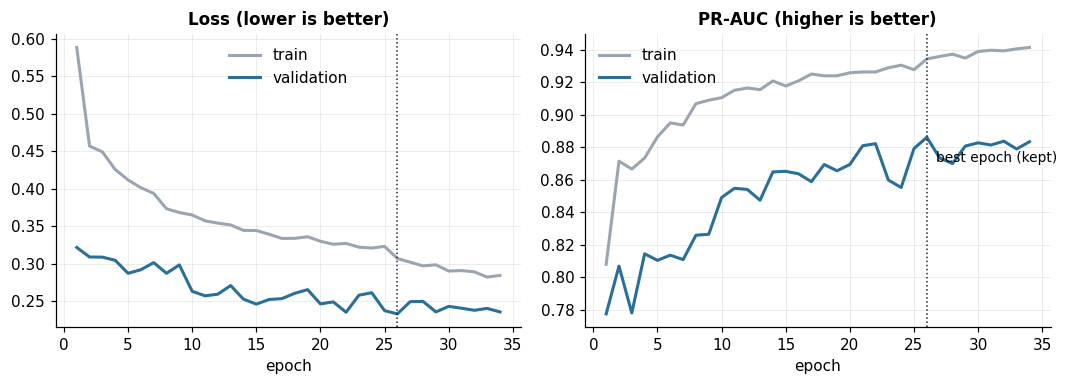

In [7]:
# =============================================================================
# FIGURE: TRAINING CURVES
# =============================================================================
h = history.history
ep = np.arange(1, len(h["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, key, title in [(axes[0], "loss", "Loss (lower is better)"),
                       (axes[1], "pr_auc", "PR-AUC (higher is better)")]:
    ax.plot(ep, h[key], color=MUTED, linewidth=2, label="train")
    ax.plot(ep, h[f"val_{key}"], color=MAIN, linewidth=2, label="validation")
    ax.axvline(best_epoch, color="#1f2933", linewidth=1, linestyle=":")
    ax.set_title(title); ax.set_xlabel("epoch")
    ax.legend(frameon=False)
axes[1].annotate("best epoch (kept)", (best_epoch, h["val_pr_auc"][best_epoch - 1]),
                 xytext=(6, -16), textcoords="offset points", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_training_curves.png"))
plt.show()

### Reading the curves

If the training line keeps improving while the validation line flattens or
turns the other way, the model has started **memorising** training windows
instead of learning goat behaviour. That's overfitting. The dotted line marks
the epoch we kept, before that happened.

In the first few epochs the validation line often jumps around. Batch
normalisation is still learning the typical scale of each layer's output, and
validation uses those estimates. Once they settle, the line calms down. That's
normal and not a sign of a problem.

## Choose the threshold on validation, then test once

Exactly the same procedure as the Random Forest: slide the threshold on the
validation set, keep the best F1 (ties go to the value nearest 0.5), apply it to
the test set, and look at the test set only this once.

In [8]:
# =============================================================================
# THRESHOLD (validation) AND TEST EVALUATION
# =============================================================================
p_val = model.predict(ds_va, verbose=0).ravel()
thresholds = np.round(np.arange(0.05, 0.96, 0.01), 2)
val_f1s = np.array([f1_score(y_va, (p_val >= t).astype(int), zero_division=0) for t in thresholds])
tied = thresholds[val_f1s >= val_f1s.max() - 1e-9]
THRESHOLD = float(tied[np.argmin(np.abs(tied - 0.5))])
val_f1_05 = float(val_f1s[np.argmin(np.abs(thresholds - 0.5))])
print(f"Validation threshold: {THRESHOLD:.2f}  (val F1 {val_f1s.max():.4f}, vs {val_f1_05:.4f} at 0.50)")

p_test = model.predict(ds_te, verbose=0).ravel()


def metrics_at(p, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(t),
        "accuracy": float(accuracy_score(y_te, pred)),
        "precision": float(precision_score(y_te, pred, zero_division=0)),
        "recall": float(recall_score(y_te, pred, zero_division=0)),
        "f1": float(f1_score(y_te, pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) else 0.0,
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    }


test_tuned = metrics_at(p_test, THRESHOLD)
test_05 = metrics_at(p_test, 0.5)
roc_auc = float(roc_auc_score(y_te, p_test))
pr_auc = float(average_precision_score(y_te, p_test))

col_t = f"threshold {THRESHOLD:.2f} (chosen)"
rows = [{"metric": k, col_t: test_tuned[k], "threshold 0.50": test_05[k]}
        for k in ["accuracy", "precision", "recall", "specificity", "f1"]]
rows += [{"metric": "ROC-AUC", col_t: roc_auc, "threshold 0.50": roc_auc},
         {"metric": "PR-AUC", col_t: pr_auc, "threshold 0.50": pr_auc}]
print(f"\nTEST SET  ({len(y_te):,} windows, {int(y_te.sum()):,} eating)\n")
pd.DataFrame(rows).set_index("metric").round(4)

Validation threshold: 0.44  (val F1 0.8086, vs 0.8051 at 0.50)

TEST SET  (5,857 windows, 590 eating)



,threshold 0.44 (chosen),threshold 0.50
metric,,
accuracy,0.9117,0.9213
precision,0.5408,0.5780
recall,0.8203,0.8102
specificity,0.9220,0.9337
f1,0.6519,0.6747
ROC-AUC,0.9477,0.9477
PR-AUC,0.7360,0.7360


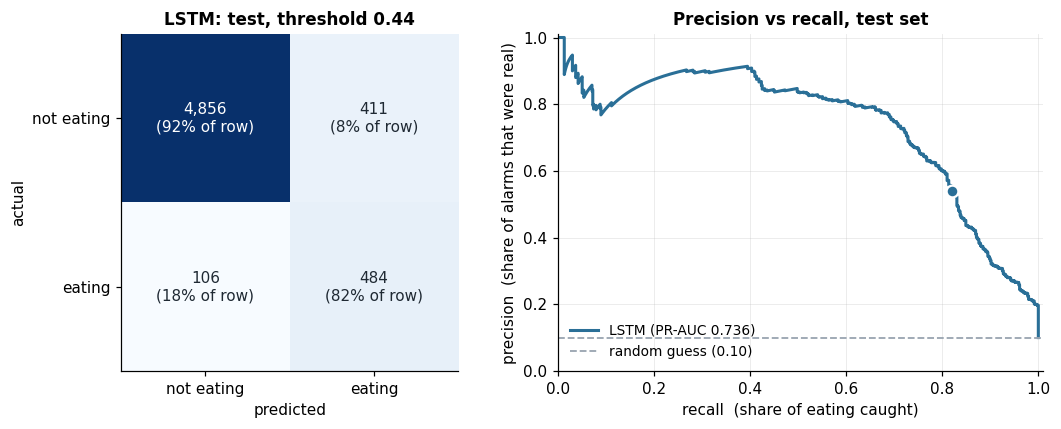

In [9]:
# =============================================================================
# FIGURES: CONFUSION MATRIX AND PRECISION-RECALL CURVE
# =============================================================================
cm = np.array(test_tuned["confusion_matrix"])
prec, rec, _ = precision_recall_curve(y_te, p_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.0), gridspec_kw={"width_ratios": [1, 1.2]})
ax1.imshow(cm, cmap="Blues"); ax1.grid(False)
names = ["not eating", "eating"]
ax1.set_xticks([0, 1], names); ax1.set_yticks([0, 1], names)
ax1.set_xlabel("predicted"); ax1.set_ylabel("actual")
for i in range(2):
    for j in range(2):
        share = cm[i, j] / cm[i].sum() if cm[i].sum() else 0
        ax1.text(j, i, f"{cm[i, j]:,}\n({share:.0%} of row)", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() * 0.55 else "#1f2933", fontsize=10)
ax1.set_title(f"{MODEL_NAME}: test, threshold {THRESHOLD:.2f}")

ax2.plot(rec, prec, color=MAIN, linewidth=2, label=f"{MODEL_NAME} (PR-AUC {pr_auc:.3f})")
ax2.axhline(y_te.mean(), color=MUTED, linewidth=1.2, linestyle="--",
            label=f"random guess ({y_te.mean():.2f})")
ax2.scatter([test_tuned["recall"]], [test_tuned["precision"]], s=60, color=MAIN,
            edgecolor="white", linewidth=1.5, zorder=3)
ax2.set_xlim(0, 1.01); ax2.set_ylim(0, 1.01)
ax2.set_xlabel("recall  (share of eating caught)")
ax2.set_ylabel("precision  (share of alarms that were real)")
ax2.set_title("Precision vs recall, test set")
ax2.legend(loc="lower left", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_confusion_pr.png"))
plt.show()

## What does this model confuse with eating?

Same breakdown as the Random Forest, so you can compare them directly. For the
forest, `scratch_biting` was the main false alarm (48% flagged), because a goat
nibbling its own flank has its head down and its jaw moving, just like grazing.
Check whether this model does better on it.

                windows flagged_as_eating
activity                                 
grazing             590             82.0%
scratch_biting       54             46.3%
fighting             44             15.9%
standing           3240              9.0%
walking             819              6.8%
lying               988              3.0%
running              57              0.0%
trotting             65              0.0%


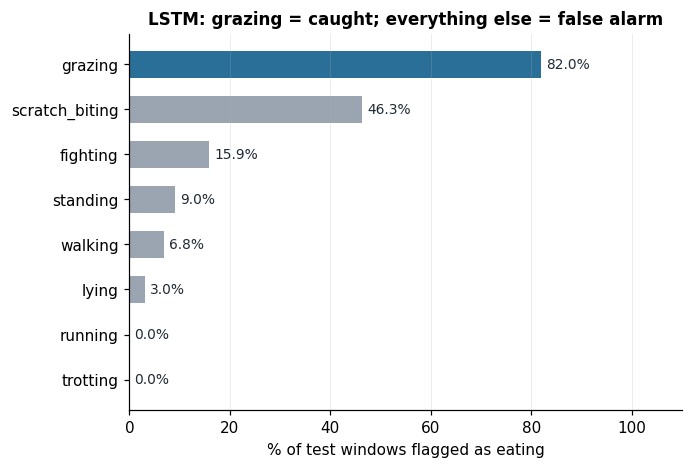

In [10]:
# =============================================================================
# ERROR ANALYSIS BY ORIGINAL ACTIVITY
# =============================================================================
pred_te = (p_test >= THRESHOLD).astype(int)
by_act = (pd.DataFrame({"activity": labels[te], "flagged": pred_te})
            .groupby("activity")["flagged"].agg(windows="size", flagged_as_eating="mean")
            .sort_values("flagged_as_eating", ascending=False))
tbl = by_act.copy()
tbl["flagged_as_eating"] = (tbl["flagged_as_eating"] * 100).round(1).astype(str) + "%"
print(tbl.to_string())

fig, ax = plt.subplots(figsize=(6.4, 0.42 * len(by_act) + 1.0))
acts = by_act.index.tolist()[::-1]
vals = by_act["flagged_as_eating"].values[::-1] * 100
ax.barh(acts, vals, color=[MAIN if a == "grazing" else MUTED for a in acts], height=0.6)
for yi, v in enumerate(vals):
    ax.text(v + 1, yi, f"{v:.1f}%", va="center", fontsize=9, color="#1f2933")
ax.set_xlim(0, 110)
ax.set_xlabel("% of test windows flagged as eating")
ax.set_title(f"{MODEL_NAME}: grazing = caught; everything else = false alarm")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, f"{TAG}_by_activity.png"))
plt.show()

## Could it run on the collar?

We measure the saved model size, the number of weights, and the time to decide
on **one** window at a time, which is how the collar would see the data. Unlike
the Random Forest, there is no feature-extraction step: the network reads the
normalised signal directly.

In [11]:
# =============================================================================
# SIZE AND SPEED
# =============================================================================
model.save(ckpt_path)                        # best weights (restored by early stopping)
size_mb = os.path.getsize(ckpt_path) / 1e6

infer = tf.function(lambda x: model(x, training=False))
one = tf.constant(X_te[:1])
for _ in range(5):                           # warm-up: the first calls build the graph
    infer(one)
idx = np.arange(min(500, len(X_te)))
t0 = time.time()
for i in idx:
    infer(tf.constant(X_te[i:i + 1]))
ms_per_window = 1000 * (time.time() - t0) / len(idx)

print(f"Saved model file:   {size_mb:.2f} MB  ({ckpt_path})")
print(f"Weights:            {N_PARAMS:,}")
print(f"INT8 estimate:      {N_PARAMS / 1e6:.3f} MB  (one byte per weight)")
print(f"Decision time:      {ms_per_window:.2f} ms per window, one at a time, on this laptop")

Saved model file:   0.43 MB  (outputs_kamminga\models\M1_4_LSTM.keras)
Weights:            31,681
INT8 estimate:      0.032 MB  (one byte per weight)
Decision time:      10.15 ms per window, one at a time, on this laptop


In [12]:
# =============================================================================
# SAVE RESULTS
# =============================================================================
results = {
    "model": MODEL_NAME,
    "tag": TAG,
    "type": "deep learning, recurrent",
    "input": f"raw normalised signal, {TIMESTEPS} x {CHANNELS} per 2 s window",
    "alpha": ALPHA,
    "epochs_run": epochs_run,
    "best_epoch": best_epoch,
    "val_f1_at_0.5": val_f1_05,
    "threshold": THRESHOLD,
    "test": {**test_tuned, "roc_auc": roc_auc, "pr_auc": pr_auc},
    "test_at_0.5": test_05,
    "model_size_mb": round(size_mb, 3),
    "int8_estimate_mb": round(N_PARAMS / 1e6, 3),
    "complexity": {"parameters": N_PARAMS},
    "ms_per_window": round(ms_per_window, 3),
    "train_seconds": round(train_seconds, 1),
    "test_windows": int(len(y_te)),
    "test_eating_windows": int(y_te.sum()),
    "false_alarm_by_activity": {a: float(v) for a, v in by_act["flagged_as_eating"].items()},
}
res_path = os.path.join(RESULTS_DIR, f"{TAG}.json")
with open(res_path, "w") as fh:
    json.dump(results, fh, indent=2)
print(f"Saved: {res_path}")
print(f"test F1 {test_tuned['f1']:.4f}   recall {test_tuned['recall']:.4f}   "
      f"precision {test_tuned['precision']:.4f}   PR-AUC {pr_auc:.4f}")

Saved: outputs_kamminga\results\M1_4_LSTM.json
test F1 0.6519   recall 0.8203   precision 0.5408   PR-AUC 0.7360


## Scoreboard so far

This cell reads every results file in `outputs_kamminga/results/`, so the table
grows as you train more models. It's a preview. The full comparison notebook at
the end adds the charts and the final choice.

In [13]:
# =============================================================================
# SCOREBOARD: EVERY M1 MODEL TRAINED SO FAR
# =============================================================================
rows = []
for p in sorted(glob.glob(os.path.join(RESULTS_DIR, "M1_*.json"))):
    r = json.load(open(p))
    rows.append({
        "model": r["model"],
        "F1": r["test"]["f1"],
        "F1 @0.5": r["test_at_0.5"]["f1"],
        "recall": r["test"]["recall"],
        "precision": r["test"]["precision"],
        "PR-AUC": r["test"]["pr_auc"],
        "size MB": r["model_size_mb"],
        "ms/window": r["ms_per_window"],
    })
pd.DataFrame(rows).set_index("model").round(4)

,F1,F1 @0.5,recall,precision,PR-AUC,size MB,ms/window
model,,,,,,,
Random Forest,0.8234,0.8474,0.9441,0.7300,0.9453,6.193,23.085
1D CNN,0.7432,0.7796,0.9492,0.6107,0.9099,1.421,2.613
LSTM,0.6519,0.6747,0.8203,0.5408,0.7360,0.428,10.155


---

## What to write in your report about this model

1. **Method.** Raw normalised 400 × 6 windows, the architecture above, weighted
   binary cross-entropy with α = the class ratio, Adam optimiser, early stopping
   on validation PR-AUC, trained from scratch.
2. **Result.** Test F1, recall, precision and PR-AUC, beside the Random Forest's.
3. **Errors.** Did `scratch_biting` still fool it? Compare with the forest.
4. **Deployability.** Weights, INT8 size estimate and decision time. Compare the
   INT8 size with the forest's 6.2 MB file.

## Next

`M1_5_CNN_LSTM.ipynb`, which puts a CNN in front of an LSTM, the combination proposed for the collar.